In [2]:
from sbcasdiego.Datasets.DefaultDataset import DefaultDataset
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("datasets/dropout.csv", sep=";")
df['Target'] = df['Target'].map({'Graduate': 1, 'Dropout': 0, 'Enrolled': 1})

In [4]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [5]:
h = DefaultDataset(
    dataset= df,
    predicted_attr="Target",
    protected_attr=['Gender'],
    protected_attr_mappings={"sex": {"Female": [0], "Male": [1]}},
    positive_outcome=1
)
# h.num_repetitions = 1
# h.execute_models()

Text(0.5, 1.0, 'Feature Correlations')

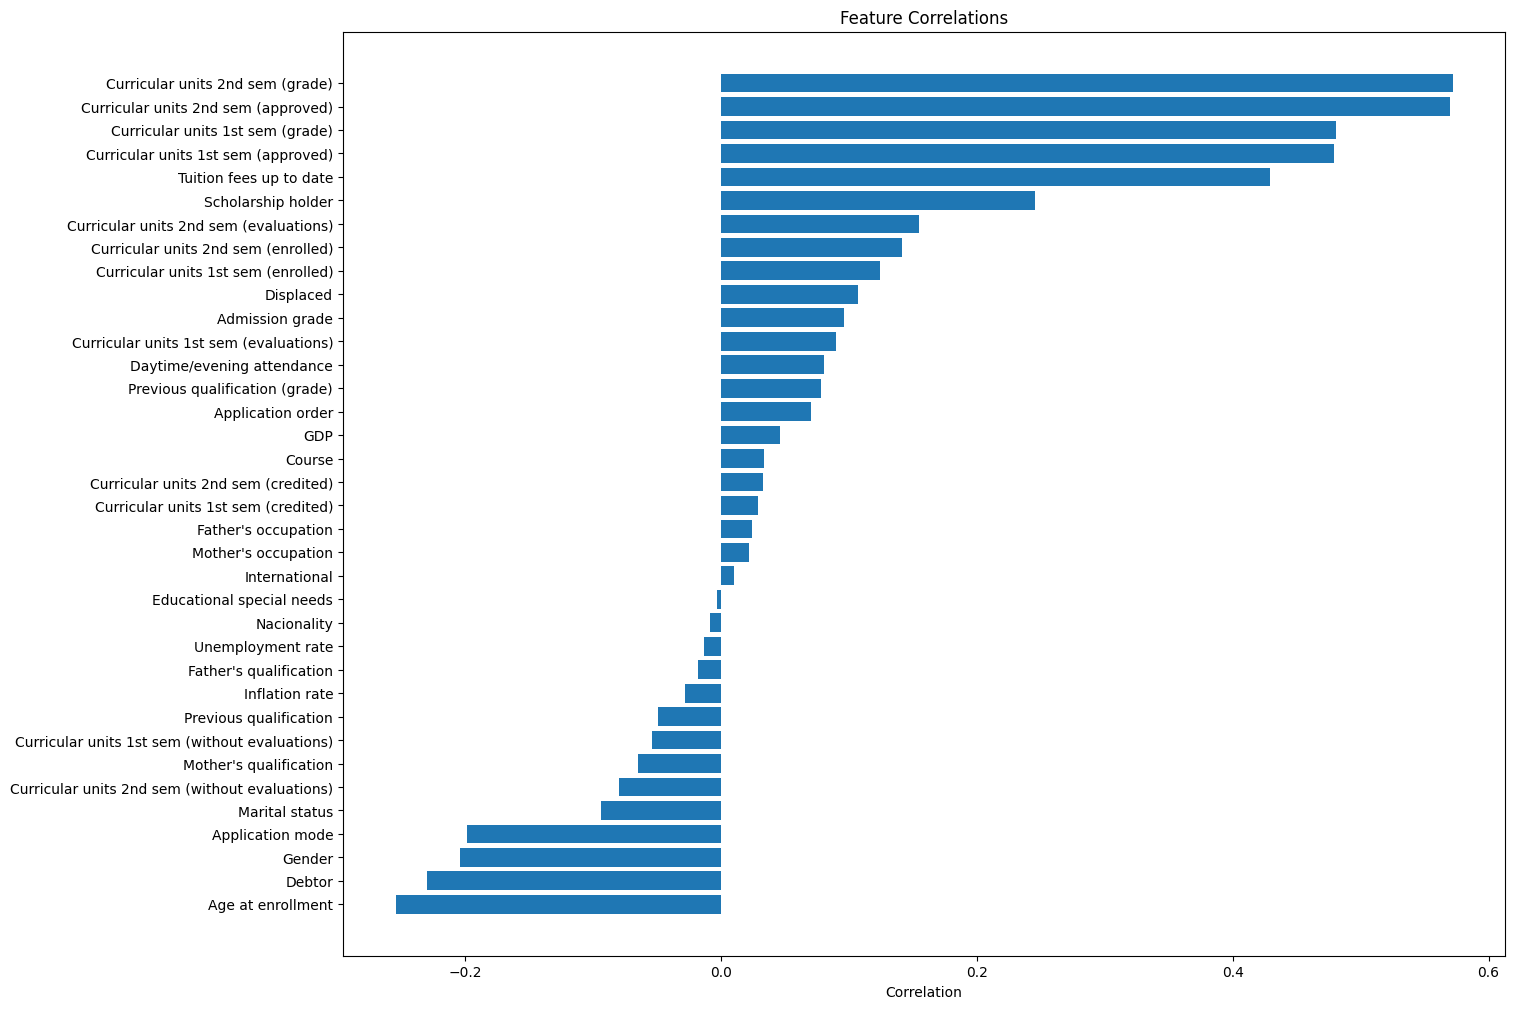

In [6]:
correlations = df.corr()['Target'].drop('Target').sort_values()
# plot correlations
plt.figure(figsize=(15, 12))
plt.barh(correlations.index, correlations, align='center')
plt.xlabel('Correlation')
plt.title('Feature Correlations')


In [ ]:
h.get_metrics(correlated_vars=[
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'],
    df_train=df)

{'Class Imbalance (Gender)': -0.2965641952983725,
 'KL Divergence (Gender)': 0.09326682832469024,
 'KS (Gender)': 0.1994681137128782,
 'CDDL (Gender, Curricular units 2nd sem (approved))': -0.06974945910305064,
 'CDDL (Gender, Curricular units 2nd sem (grade))': -0.2454635663425534}

In [16]:
protected_attr_mappings = {}
for column in df.columns:
    if df[column].nunique() == 2 and column != h.predicted_attr:
        protected_attr_mappings[column] = {"Privileged": df[column].value_counts().idxmax(), "Unprivileged": df[column].value_counts().idxmin()}
protected_attr_mappings

{'Daytime/evening attendance': {'Privileged': 1, 'Unprivileged': 0},
 'Displaced': {'Privileged': 1, 'Unprivileged': 0},
 'Educational special needs': {'Privileged': 0, 'Unprivileged': 1},
 'Debtor': {'Privileged': 0, 'Unprivileged': 1},
 'Tuition fees up to date': {'Privileged': 1, 'Unprivileged': 0},
 'Gender': {'Privileged': 0, 'Unprivileged': 1},
 'Scholarship holder': {'Privileged': 0, 'Unprivileged': 1},
 'International': {'Privileged': 0, 'Unprivileged': 1}}

In [17]:
h.protected_attr_mappings = protected_attr_mappings
h.protected_attr = list(protected_attr_mappings.keys())
h.get_metrics(correlated_vars=[
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'],
    df_train=df)

{'Class Imbalance (Daytime/evening attendance)': 0.7816455696202531,
 'KL Divergence (Daytime/evening attendance)': 0.0307080326948435,
 'KS (Daytime/evening attendance)': 0.12052778482618631,
 'CDDL (Daytime/evening attendance, Curricular units 2nd sem (approved))': 0.05721940778465267,
 'CDDL (Daytime/evening attendance, Curricular units 2nd sem (grade))': 0.026511599566295917,
 'Class Imbalance (Displaced)': 0.09674502712477397,
 'KL Divergence (Displaced)': 0.022550046825151673,
 'KS (Displaced)': 0.10061380424117439,
 'CDDL (Displaced, Curricular units 2nd sem (approved))': 0.0719255704615986,
 'CDDL (Displaced, Curricular units 2nd sem (grade))': 0.022644918669217924,
 'Class Imbalance (Educational special needs)': -0.9769439421338155,
 'KL Divergence (Educational special needs)': 0.0003432050803490669,
 'KS (Educational special needs)': 0.01227227685036969,
 'CDDL (Educational special needs, Curricular units 2nd sem (approved))': -0.0030187161865842514,
 'CDDL (Educational speci